# Feed Forward Neural Network


**Experiments run:**

| # | Experiment            | Spatial unit   | Temporal bin | Comparison group |
|---|-----------------------|----------------|--------------|-------------------|
| 1 | Community Area (1h)   | Community Area | 1 hour       | Spatial & Temporal (baseline) |
| 2 | Census Tract (1h)     | Census Tract   | 1 hour       | Spatial |
| 3 | Community Area (4h)   | Community Area | 4 hours      | Temporal |
| 4 | Community Area (1d)   | Community Area | 1 day        | Temporal |

For every experiment we train **the same architecture** with **the same
hyperparameters** (found once via a grid search on the baseline dataset),
using the **same train/validation/test split methodology** (three pre-split
parquet files per dataset) and **the same preprocessing** steps. This keeps
the comparison fair: any difference in performance can be attributed to the
spatial or temporal resolution of the data, not to differences in modeling
choices.

For each experiment we report:
- **R² (Coefficient of Determination)**
- **MAPE (Mean Absolute Percentage Error)**


## 1. Setup

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")  # silence the benign "non-writable array" cast warning


In [2]:
# Reproducibility: fix every relevant random seed so the notebook gives the
# same results every time it's re-run from top to bottom.
SEED = 42

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Model architecture

In [3]:
class Model(nn.Module):
    """Simple feed-forward regressor: input -> fc1 -> fc2 -> output."""

    def __init__(self, input_dim, hidden1, hidden2, dropout, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.out(x)
        return x


## 3. Dataset registry

In [4]:
BASE_DIR = r"C:\Users\GESADIK\OneDrive - Mercedes-Benz (corpdir.onmicrosoft.com)\Desktop\PhD\Advanced Analytics and Applications\Project\03_2026_06_26\03"

def paths(prefix):
    """Build the {train, val, test} path dict for a given file prefix."""
    return {
        "train": os.path.join(BASE_DIR, f"{prefix}_train.parquet"),
        "val":   os.path.join(BASE_DIR, f"{prefix}_val.parquet"),
        "test":  os.path.join(BASE_DIR, f"{prefix}_test.parquet"),
    }

# group: "spatial"  -> part of the Community Area vs Census Tract comparison
#        "temporal" -> part of the 1h vs 4h vs 1d comparison
#        "both"     -> the shared 1h / Community Area baseline
DATASETS = {
    "Community Area (1h)": {"paths": paths("03_community_area_1h"), "group": "both",
                             "spatial_unit": "Community Area", "temporal_bin": "1 hour"},
    "Census Tract (1h)":    {"paths": paths("03_census_tract_1h"),  "group": "spatial",
                             "spatial_unit": "Census Tract",   "temporal_bin": "1 hour"},
    "Community Area (4h)":  {"paths": paths("03_community_area_4h"), "group": "temporal",
                              "spatial_unit": "Community Area", "temporal_bin": "4 hours"},
    "Community Area (1d)":  {"paths": paths("03_community_area_1d"), "group": "temporal",
                              "spatial_unit": "Community Area", "temporal_bin": "1 day"},
}

list(DATASETS.keys())


['Community Area (1h)',
 'Census Tract (1h)',
 'Community Area (4h)',
 'Community Area (1d)']

## 4. Data loading & preprocessing

The same preprocessing pipeline is applied **identically** to every dataset:

1. Read the pre-split train / validation / test parquet files.
2. Separate the target column (`trip_count`) from the features.
3. **Standardize features** (zero mean, unit variance), fit on the training
   split only and applied unchanged to validation/test.
4. Convert everything to `float32` PyTorch tensors.

In [5]:
def load_and_prepare(path_dict, target_col="trip_count", verbose=True):
    """Load the train/val/test parquet files for one experiment, standardize
    features (fit on train only), and return ready-to-train tensors plus the
    input feature dimension."""

    train_db = pd.read_parquet(path_dict["train"])
    val_db   = pd.read_parquet(path_dict["val"])
    test_db  = pd.read_parquet(path_dict["test"])

    X_train_df = train_db.drop(columns=[target_col])
    Y_train_df = train_db[target_col]

    X_val_df = val_db.drop(columns=[target_col])
    Y_val_df = val_db[target_col]

    X_test_df = test_db.drop(columns=[target_col])
    Y_test_df = test_db[target_col]

    if verbose:
        # Quick sanity check: flag any feature column with an unusually large
        # magnitude BEFORE scaling, and report the target's raw range.
        col_max_abs = X_train_df.abs().max().sort_values(ascending=False)
        print(f"  Target range: [{Y_train_df.min():.2f}, {Y_train_df.max():.2f}]")
        print(f"  Largest-magnitude feature: '{col_max_abs.index[0]}' (max abs value = {col_max_abs.iloc[0]:.2f})")

    # Standardize features: fit the scaler on the training split only, then
    # apply the SAME transform to validation/test (never fit on val/test).
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df.values)
    X_val_scaled   = scaler.transform(X_val_df.values)
    X_test_scaled  = scaler.transform(X_test_df.values)

    X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
    Y_train = torch.tensor(Y_train_df.values, dtype=torch.float32)

    X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
    Y_val = torch.tensor(Y_val_df.values, dtype=torch.float32)

    X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
    Y_test = torch.tensor(Y_test_df.values, dtype=torch.float32)

    data = {
        "X_train": X_train, "Y_train": Y_train,
        "X_val":   X_val,   "Y_val":   Y_val,
        "X_test":  X_test,  "Y_test":  Y_test,
        "input_dim": X_train.shape[1],
        "n_train": X_train.shape[0], "n_val": X_val.shape[0], "n_test": X_test.shape[0],
        "scaler": scaler,
    }
    return data


## 5. Evaluation metrics

Both metrics are computed on the (unscaled) `trip_count` target:

- **R²**: standard coefficient of determination.
- **MAPE**: mean absolute percentage error. Rows where the true value is 0 are
  excluded (percentage error is undefined when dividing by zero); the number
  of excluded rows is reported alongside the metric for transparency.

In [6]:
def compute_metrics(y_true, y_pred):
    """Return R^2 and MAPE (%) for a set of predictions."""
    y_true = y_true.detach().cpu().numpy().flatten()
    y_pred = y_pred.detach().cpu().numpy().flatten()

    r2 = r2_score(y_true, y_pred)

    nonzero_mask = y_true != 0
    n_excluded = int((~nonzero_mask).sum())
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

    return {"r2": r2, "mape": mape, "mape_excluded_rows": n_excluded}


## 6. Hyperparameter tuning (baseline only)

To keep the comparison fair, hyperparameter tuning is performed **once**, on
the baseline dataset (Community Area, 1-hour bins). The resulting
hyperparameters are then reused, unchanged, for every other experiment. 

In [7]:
def train_and_evaluate(params, X_tr, Y_tr, X_va, Y_va, epochs):
    """Train a fresh candidate model and return its validation MAE (L1 loss)."""
    set_seed(0)  # same starting point for every candidate -> a fair comparison

    candidate = Model(
        input_dim=X_tr.shape[1],
        hidden1=params["hidden1"],
        hidden2=params["hidden2"],
        dropout=params["dropout"],
    )
    candidate_optimizer = torch.optim.Adam(
        candidate.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    candidate_loss_fn = nn.L1Loss()

    search_loader = DataLoader(
        TensorDataset(X_tr, Y_tr), batch_size=params["batch_size"], shuffle=True
    )

    candidate.train()
    for _ in range(epochs):
        for X_batch, Y_batch in search_loader:
            Y_pred = candidate(X_batch)
            error = candidate_loss_fn(Y_pred.squeeze(), Y_batch)

            candidate_optimizer.zero_grad()
            error.backward()
            candidate_optimizer.step()

    candidate.eval()
    with torch.no_grad():
        Y_val_pred = candidate(X_va)
        val_loss = candidate_loss_fn(Y_val_pred.squeeze(), Y_va).item()

    return val_loss


In [8]:
# Load the baseline dataset used for tuning.
baseline_data = load_and_prepare(DATASETS["Community Area (1h)"]["paths"])
print(f"Baseline (Community Area, 1h) -> "
      f"train: {baseline_data['n_train']} | val: {baseline_data['n_val']} | test: {baseline_data['n_test']} | "
      f"features: {baseline_data['input_dim']}")


  Target range: [1.00, 938.00]
  Largest-magnitude feature: 'community_area' (max abs value = 77.00)
Baseline (Community Area, 1h) -> train: 617263 | val: 132270 | test: 132270 | features: 31


In [9]:
# Search on a random subsample of the training set for speed; the final
# models are still trained on the FULL training set for each experiment.
SEARCH_SAMPLE_SIZE = 70000
EPOCHS_PER_COMBO = 5

set_seed()
sample_idx = torch.randperm(baseline_data["X_train"].shape[0])[:SEARCH_SAMPLE_SIZE]
X_search = baseline_data["X_train"][sample_idx]
Y_search = baseline_data["Y_train"][sample_idx]

param_grid = {
    "hidden1":      [16, 32, 64],
    "hidden2":      [8, 16, 32],
    "lr":           [0.001, 0.003, 0.01],
    "weight_decay": [0, 1e-5, 1e-4],
    "dropout":      [0.0, 0.1, 0.2],
    "batch_size":   [64, 128],
}
grid = list(ParameterGrid(param_grid))
print(f"Total combinations to try: {len(grid)}")


Total combinations to try: 486


In [10]:
results = []
start = time.time()

for i, params in enumerate(grid, 1):
    val_loss = train_and_evaluate(
        params, X_search, Y_search,
        baseline_data["X_val"], baseline_data["Y_val"],
        epochs=EPOCHS_PER_COMBO,
    )
    results.append({**params, "val_loss": val_loss})
    print(f"[{i}/{len(grid)}] val_loss={val_loss:.4f}  (elapsed: {time.time() - start:.0f}s)")

results_df = pd.DataFrame(results).sort_values("val_loss").reset_index(drop=True)
best_params = results_df.iloc[0].to_dict()

print("\nBest hyperparameters found (used for ALL experiments below):")
for k, v in best_params.items():
    if k != "val_loss":
        print(f"  {k}: {v}")
print(f"  -> baseline validation MAE: {best_params['val_loss']:.4f}")


[1/486] val_loss=6.9560  (elapsed: 6s)
[2/486] val_loss=6.9997  (elapsed: 11s)
[3/486] val_loss=7.0654  (elapsed: 15s)
[4/486] val_loss=6.0716  (elapsed: 20s)
[5/486] val_loss=6.2207  (elapsed: 24s)
[6/486] val_loss=6.3246  (elapsed: 29s)
[7/486] val_loss=6.7097  (elapsed: 33s)
[8/486] val_loss=6.6712  (elapsed: 37s)
[9/486] val_loss=6.4283  (elapsed: 42s)
[10/486] val_loss=6.5947  (elapsed: 47s)
[11/486] val_loss=6.5302  (elapsed: 51s)
[12/486] val_loss=6.5673  (elapsed: 56s)
[13/486] val_loss=5.8676  (elapsed: 61s)
[14/486] val_loss=6.0118  (elapsed: 66s)
[15/486] val_loss=5.8248  (elapsed: 71s)
[16/486] val_loss=5.5935  (elapsed: 76s)
[17/486] val_loss=5.5657  (elapsed: 82s)
[18/486] val_loss=5.7793  (elapsed: 87s)
[19/486] val_loss=6.6699  (elapsed: 92s)
[20/486] val_loss=6.5045  (elapsed: 99s)
[21/486] val_loss=6.6069  (elapsed: 104s)
[22/486] val_loss=6.6320  (elapsed: 110s)
[23/486] val_loss=6.6642  (elapsed: 115s)
[24/486] val_loss=6.5625  (elapsed: 121s)
[25/486] val_loss=6.34

## 7. Final training routine

A single function trains a full model on a given training set using the
shared `best_params`, tracking the loss curve for later plotting. This exact
function is reused for every experiment so training is identical across all
of them (same architecture, same optimizer, same batch size, same number of
epochs).

In [11]:
FINAL_EPOCHS = 30  # kept identical for every experiment

def train_final_model(data, params, epochs=FINAL_EPOCHS):
    """Train a model on the full training set of one experiment's dataset."""
    set_seed(0)  # same initial weights for every experiment -> fair comparison

    model = Model(
        input_dim=data["input_dim"],
        hidden1=int(params["hidden1"]),
        hidden2=int(params["hidden2"]),
        dropout=params["dropout"],
        out_features=1,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    loss_fn = nn.L1Loss()

    train_loader = DataLoader(
        TensorDataset(data["X_train"], data["Y_train"]),
        batch_size=int(params["batch_size"]),
        shuffle=True,
    )

    loss_history = []
    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for X_batch, Y_batch in train_loader:
            Y_pred = model(X_batch).squeeze()
            error = loss_fn(Y_pred, Y_batch)

            optimizer.zero_grad()
            error.backward()
            optimizer.step()

            epoch_loss += error.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

    return model, loss_history


## 8. Run every experiment

For each dataset in the registry: load & preprocess the data, train a model
with the shared hyperparameters, then evaluate on the held-out test set.

In [12]:
experiment_results = []
loss_curves = {}
predictions = {}

for name, cfg in DATASETS.items():
    print(f"\n=== {name} ===")

    data = baseline_data if name == "Community Area (1h)" else load_and_prepare(cfg["paths"])
    print(f"train: {data['n_train']} | val: {data['n_val']} | test: {data['n_test']} | features: {data['input_dim']}")

    t0 = time.time()
    model, loss_history = train_final_model(data, best_params)
    print(f"Trained in {time.time() - t0:.0f}s -> final training loss: {loss_history[-1]:.4f}")

    model.eval()
    with torch.no_grad():
        y_pred_test = model(data["X_test"]).squeeze()

    metrics = compute_metrics(data["Y_test"], y_pred_test)
    print(f"Test R^2: {metrics['r2']:.4f} | Test MAPE: {metrics['mape']:.2f}% "
          f"(excluded {metrics['mape_excluded_rows']} zero-count rows)")

    # Prediction-collapse check: if the model just learned to predict close
    # to a constant (e.g. the target's mean), pred_std will be tiny relative
    # to actual_std even though R^2/MAPE alone might not make that obvious.
    y_true_np = data["Y_test"].detach().cpu().numpy().flatten()
    y_pred_np = y_pred_test.detach().cpu().numpy().flatten()
    pred_std_ratio = y_pred_np.std() / y_true_np.std() if y_true_np.std() > 0 else float("nan")
    print(f"Actual: mean={y_true_np.mean():.2f}, std={y_true_np.std():.2f} | "
          f"Predicted: mean={y_pred_np.mean():.2f}, std={y_pred_np.std():.2f} | "
          f"pred_std/actual_std={pred_std_ratio:.3f}")
    if pred_std_ratio < 0.2:
        print("  Warning: predicted values vary far less than actual values -- "
              "the model may have collapsed toward predicting a near-constant value.")

    experiment_results.append({
        "experiment": name,
        "group": cfg["group"],
        "spatial_unit": cfg["spatial_unit"],
        "temporal_bin": cfg["temporal_bin"],
        "n_train": data["n_train"],
        "n_test": data["n_test"],
        "input_dim": data["input_dim"],
        "r2": metrics["r2"],
        "mape": metrics["mape"],
    })
    loss_curves[name] = loss_history
    predictions[name] = (y_true_np, y_pred_np)



=== Community Area (1h) ===
train: 617263 | val: 132270 | test: 132270 | features: 31
Trained in 345s -> final training loss: 3.4457
Test R^2: 0.8562 | Test MAPE: 36.71% (excluded 0 zero-count rows)
Actual: mean=16.12, std=47.49 | Predicted: mean=12.42, std=38.03 | pred_std/actual_std=0.801

=== Census Tract (1h) ===
  Target range: [1.00, 532.00]
  Largest-magnitude feature: 'census_tract' (max abs value = 17031980100.00)
train: 271145 | val: 58102 | test: 58102 | features: 31
Trained in 156s -> final training loss: 8.8247
Test R^2: 0.3686 | Test MAPE: 75.00% (excluded 0 zero-count rows)
Actual: mean=14.73, std=22.73 | Predicted: mean=8.79, std=13.30 | pred_std/actual_std=0.585

=== Community Area (4h) ===
  Target range: [1.00, 3260.00]
  Largest-magnitude feature: 'community_area' (max abs value = 77.00)
train: 222424 | val: 47662 | test: 47662 | features: 31
Trained in 130s -> final training loss: 7.9470
Test R^2: 0.8952 | Test MAPE: 71.69% (excluded 0 zero-count rows)
Actual: mea

## 9. Results table

In [13]:
results_df = pd.DataFrame(experiment_results)
results_df = results_df[["experiment", "group", "spatial_unit", "temporal_bin",
                          "n_train", "n_test", "input_dim", "r2", "mape"]]
results_df.style.format({
    "r2": "{:.4f}", "mape": "{:.2f}%",
})


,experiment,group,spatial_unit,temporal_bin,n_train,n_test,input_dim,r2,mape
0,Community Area (1h),both,Community Area,1 hour,617263,132270,31,0.8562,36.71%
1,Census Tract (1h),spatial,Census Tract,1 hour,271145,58102,31,0.3686,75.00%
2,Community Area (4h),temporal,Community Area,4 hours,222424,47662,31,0.8952,71.69%
3,Community Area (1d),temporal,Community Area,1 day,45352,9718,31,0.9038,109.67%


## 10. Spatial resolution comparison

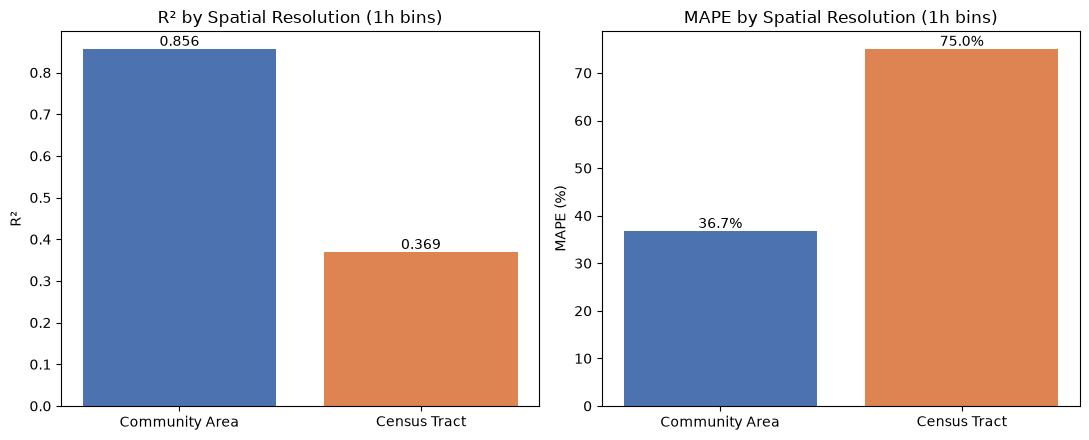

In [14]:
spatial_df = results_df[results_df["group"].isin(["spatial", "both"])].copy()
spatial_df = spatial_df[spatial_df["temporal_bin"] == "1 hour"]
spatial_df = spatial_df.set_index("spatial_unit").loc[["Community Area", "Census Tract"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(spatial_df.index, spatial_df["r2"], color=["#4C72B0", "#DD8452"])
axes[0].set_title("R² by Spatial Resolution (1h bins)")
axes[0].set_ylabel("R²")
axes[0].set_ylim(bottom=min(0, spatial_df["r2"].min() * 1.1))
for i, v in enumerate(spatial_df["r2"]):
    axes[0].text(i, v, f"{v:.3f}", ha="center", va="bottom" if v >= 0 else "top")

axes[1].bar(spatial_df.index, spatial_df["mape"], color=["#4C72B0", "#DD8452"])
axes[1].set_title("MAPE by Spatial Resolution (1h bins)")
axes[1].set_ylabel("MAPE (%)")
for i, v in enumerate(spatial_df["mape"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("spatial_resolution_comparison.png", dpi=200)
plt.show()


## 11. Temporal resolution comparison

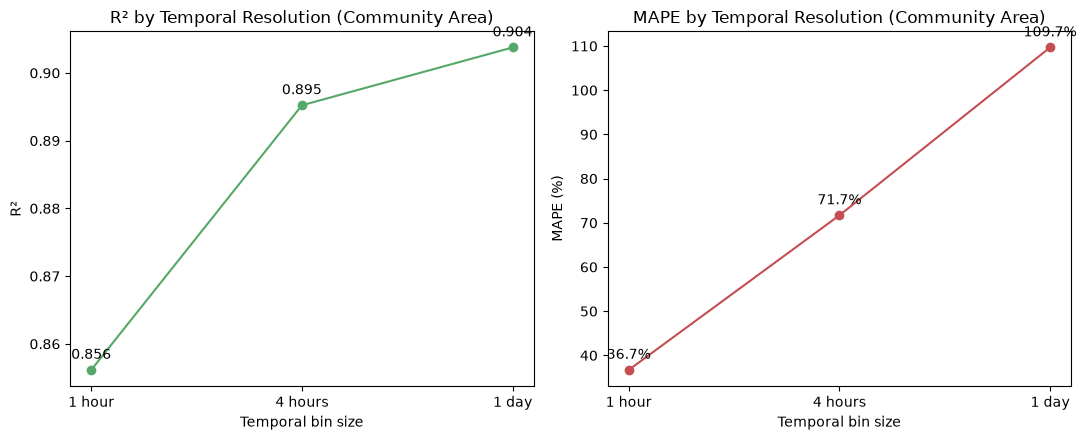

In [15]:
temporal_order = ["1 hour", "4 hours", "1 day"]
temporal_df = results_df[results_df["group"].isin(["temporal", "both"])].copy()
temporal_df = temporal_df.set_index("temporal_bin").loc[temporal_order]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(temporal_df.index, temporal_df["r2"], marker="o", color="#55A868")
axes[0].set_title("R² by Temporal Resolution (Community Area)")
axes[0].set_ylabel("R²")
axes[0].set_xlabel("Temporal bin size")
for x, v in zip(temporal_df.index, temporal_df["r2"]):
    axes[0].annotate(f"{v:.3f}", (x, v), textcoords="offset points", xytext=(0, 8), ha="center")

axes[1].plot(temporal_df.index, temporal_df["mape"], marker="o", color="#C44E52")
axes[1].set_title("MAPE by Temporal Resolution (Community Area)")
axes[1].set_ylabel("MAPE (%)")
axes[1].set_xlabel("Temporal bin size")
for x, v in zip(temporal_df.index, temporal_df["mape"]):
    axes[1].annotate(f"{v:.1f}%", (x, v), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("temporal_resolution_comparison.png", dpi=200)
plt.show()


## 12. Training loss curves

All four experiments trained for the same number of epochs with the same
optimizer settings, so the curves are directly comparable in terms of
convergence behavior. The y-axis is log-scaled: absolute loss values can
legitimately differ by orders of magnitude between experiments (e.g. a
transient scale spike, or coarser temporal bins naturally summing to larger
trip counts), and a log scale keeps every curve's *shape* visible instead of
letting the largest one flatten the rest near zero on a linear axis.

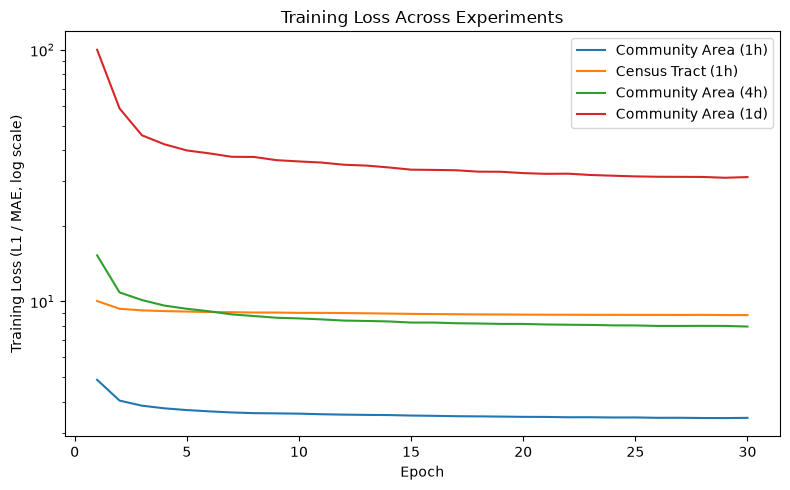

In [16]:
plt.figure(figsize=(8, 5))
for name, history in loss_curves.items():
    plt.plot(range(1, len(history) + 1), history, label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (L1 / MAE, log scale)")
plt.title("Training Loss Across Experiments")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss_curves.png", dpi=200)
plt.show()


## 13. Predicted vs. actual (test set)

A quick visual sanity check for each experiment: perfect predictions would fall on the diagonal line.

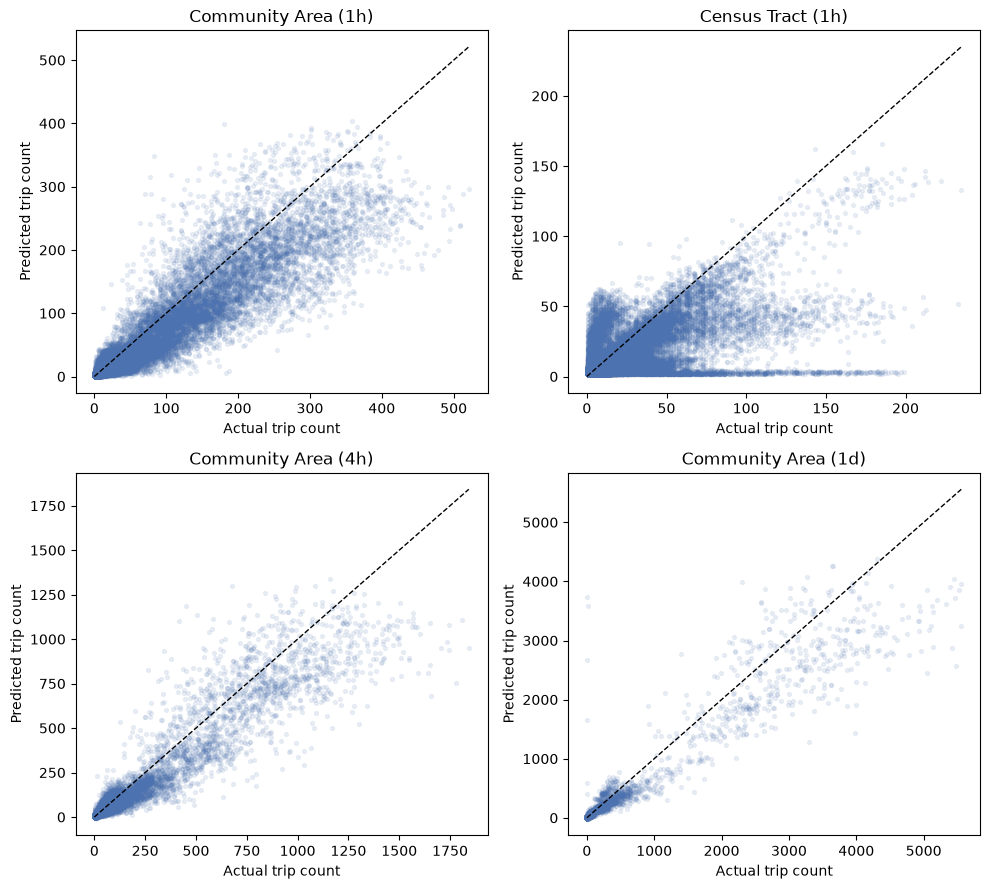

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, (name, (y_true, y_pred)) in zip(axes.flat, predictions.items()):
    ax.scatter(y_true, y_pred, alpha=0.1, s=8, color="#4C72B0")
    lims = [0, max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual trip count")
    ax.set_ylabel("Predicted trip count")

plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=200)
plt.show()


## 14. Checking number of correct predictions


In [18]:
def accuracy_report(y_true, y_pred, abs_tolerances=(0, 1, 2, 5), rel_tolerances=(0.10, 0.20)):
    """Return 'correct prediction' rates under several tolerance definitions.

    - abs_tolerances[0] == 0  -> exact match on the rounded prediction.
    - remaining abs_tolerances -> within +/- N trips of the actual count.
    - rel_tolerances           -> within +/- X% of the actual count
                                  (rows with actual == 0 are excluded, same
                                  convention as the MAPE computation above).
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred_rounded = np.round(y_pred)
    abs_err = np.abs(y_pred_rounded - y_true)

    report = {"n_test": len(y_true)}

    for tol in abs_tolerances:
        label = "exact_match" if tol == 0 else f"within_{tol}_trips"
        report[label] = float(np.mean(abs_err <= tol))

    nonzero_mask = y_true != 0
    rel_err = np.abs(y_pred[nonzero_mask] - y_true[nonzero_mask]) / y_true[nonzero_mask]
    for tol in rel_tolerances:
        label = f"within_{int(tol * 100)}pct"
        report[label] = float(np.mean(rel_err <= tol))

    return report


accuracy_rows = []
for name, (y_true, y_pred) in predictions.items():
    row = {"experiment": name}
    row.update(accuracy_report(y_true, y_pred))
    accuracy_rows.append(row)

accuracy_df = pd.DataFrame(accuracy_rows)

pct_cols = [c for c in accuracy_df.columns if c not in ("experiment", "n_test")]
accuracy_df.style.format({c: "{:.1%}" for c in pct_cols})


,experiment,n_test,exact_match,within_1_trips,within_2_trips,within_5_trips,within_10pct,within_20pct
0,Community Area (1h),132270,38.8%,63.4%,74.3%,84.8%,35.7%,43.2%
1,Census Tract (1h),58102,12.2%,34.0%,44.2%,63.0%,13.0%,19.7%
2,Community Area (4h),47662,13.3%,43.1%,55.0%,75.4%,17.2%,27.0%
3,Community Area (1d),9718,3.8%,10.8%,17.7%,36.9%,15.1%,29.7%


## 15. Save results

Write both results tables to disk so they can be dropped straight into the report.


In [19]:
results_df.to_csv("resolution_comparison_results.csv", index=False)
accuracy_df.to_csv("resolution_comparison_accuracy.csv", index=False)
print("Saved results_df to resolution_comparison_results.csv")
print("Saved accuracy_df to resolution_comparison_accuracy.csv")
results_df


Saved results_df to resolution_comparison_results.csv
Saved accuracy_df to resolution_comparison_accuracy.csv


,experiment,group,spatial_unit,temporal_bin,n_train,n_test,input_dim,r2,mape
0,Community Area (1h),both,Community Area,1 hour,617263,132270,31,0.856151,36.709648
1,Census Tract (1h),spatial,Census Tract,1 hour,271145,58102,31,0.368640,74.995438
2,Community Area (4h),temporal,Community Area,4 hours,222424,47662,31,0.895221,71.685806
3,Community Area (1d),temporal,Community Area,1 day,45352,9718,31,0.903760,109.673500
